# Data Quality - SplitLab Phase 1

Before I build anything statistical on top of this data, I want to know I can trust it.
This notebook is where I put KuaiRand-Pure through a set of checks: duplicates, missing
values, whether the "random" log is actually random, whether the two timestamp columns
agree with each other, whether every user and video I see in the logs actually has a
matching feature row, and whether the watch-time signal behaves the way I'd expect.

I'm not just running these checks and moving on, where something looks off, I dig into
why, because a bad assumption here would quietly break every later phase (the power
calculator, CUPED, the simulator, all of it).


## Setup

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# autoreload so edits to core/ show up without restarting the kernel
%load_ext autoreload
%autoreload 2

from core.artifacts import save_fig, save_table

RAW = Path("../data/raw")
pd.set_option("display.max_columns", 50)


## Loading the raw files

I load all six CSVs up front. `log_random` is the one I care about most at this stage,
because it's the only file where video exposure wasn't shaped by an existing recommender.
That's what makes it a fair source for a true baseline rate later on.

In [2]:
log_random = pd.read_csv(RAW / "log_random_4_22_to_5_08_pure.csv")
log_standard_1 = pd.read_csv(RAW / "log_standard_4_08_to_4_21_pure.csv")
log_standard_2 = pd.read_csv(RAW / "log_standard_4_22_to_5_08_pure.csv")
user_features = pd.read_csv(RAW / "user_features_pure.csv")
video_basic = pd.read_csv(RAW / "video_features_basic_pure.csv")
video_stats = pd.read_csv(RAW / "video_features_statistic_pure.csv")

print("log_random:", log_random.shape)
print("log_standard_1:", log_standard_1.shape)
print("log_standard_2:", log_standard_2.shape)
print("user_features:", user_features.shape)
print("video_basic:", video_basic.shape)
print("video_stats:", video_stats.shape)


log_random: (1186059, 19)
log_standard_1: (1141112, 19)
log_standard_2: (295497, 19)
user_features: (27285, 31)
video_basic: (7583, 12)
video_stats: (7583, 52)


A quick look at the shape of the data before I start checking it in detail:

In [3]:
log_random.head()

,user_id,video_id,date,hourmin,time_ms,is_click,is_like,is_follow,is_comment,is_forward,is_hate,long_view,play_time_ms,duration_ms,profile_stay_time,comment_stay_time,is_profile_enter,is_rand,tab
0,0,5543,20220430,1800,1651314030792,0,0,0,0,0,0,0,863,30066,0,0,0,1,1
1,0,1836,20220502,1200,1651466607423,0,0,0,0,0,0,0,1190,132433,0,0,0,1,1
2,0,721,20220502,1700,1651481542743,0,0,0,0,0,0,0,1528,25266,0,0,0,1,1
3,0,442,20220502,1800,1651488577163,0,0,0,0,0,0,0,1490,12000,0,0,0,1,1
4,0,62,20220503,800,1651535940163,0,0,0,0,0,0,0,1419,169500,0,0,0,1,1


In [4]:
log_random.dtypes

user_id              int64
video_id             int64
date                 int64
hourmin              int64
time_ms              int64
is_click             int64
is_like              int64
is_follow            int64
is_comment           int64
is_forward           int64
is_hate              int64
long_view            int64
play_time_ms         int64
duration_ms          int64
profile_stay_time    int64
comment_stay_time    int64
is_profile_enter     int64
is_rand              int64
tab                  int64
dtype: object

## Check 1 - Duplicate rows

My first check is whether the same interaction shows up more than once. I define a
duplicate as a repeat of `(user_id, video_id, time_ms)`, since that combination should
uniquely identify a single impression.


In [5]:
def duplicate_report(df: pd.DataFrame, name: str, keys=("user_id", "video_id", "time_ms")) -> dict:
    n_before = len(df)
    n_dupes = df.duplicated(subset=list(keys)).sum()
    pct = 100 * n_dupes / n_before if n_before else 0
    print(f"{name}: {n_dupes:,} duplicate rows out of {n_before:,} ({pct:.3f}%)")
    return {"file": name, "rows_before": n_before, "duplicates": int(n_dupes), "pct_duplicates": pct}


dup_reports = [
    duplicate_report(log_random, "log_random"),
    duplicate_report(log_standard_1, "log_standard_1"),
    duplicate_report(log_standard_2, "log_standard_2"),
]


log_random: 10 duplicate rows out of 1,186,059 (0.001%)
log_standard_1: 16,580 duplicate rows out of 1,141,112 (1.453%)
log_standard_2: 6,893 duplicate rows out of 295,497 (2.333%)


`log_random` comes back almost perfectly clean at 0.001%, but `log_standard_1` and
`log_standard_2` sit at 1.45% and 2.33%. That's a big enough gap that I don't want to just
drop the duplicates and move on. I want to know what they actually are first. Specifically:
are they exact repeats of the same row (safe to drop, no real information lost), or do some
of them share the same key but disagree on everything else (in which case dropping "the
first one" is a real decision, not just cleanup)?


In [6]:
def duplicate_depth_report(df: pd.DataFrame, name: str, keys=("user_id", "video_id", "time_ms")) -> dict:
    key_dupe_mask = df.duplicated(subset=list(keys), keep=False)
    full_dupe_mask = df.duplicated(keep=False)
    n_key = int(key_dupe_mask.sum())
    n_full = int(full_dupe_mask.sum())
    n_partial = n_key - n_full
    print(f"{name}: {n_key:,} rows share a key; {n_full:,} of those are exact full-row repeats; "
          f"{n_partial:,} share the key but differ in other columns")
    return {"file": name, "key_dupe_rows": n_key, "full_dupe_rows": n_full, "partial_dupe_rows": n_partial}


depth_reports = [
    duplicate_depth_report(log_random, "log_random"),
    duplicate_depth_report(log_standard_1, "log_standard_1"),
    duplicate_depth_report(log_standard_2, "log_standard_2"),
]


log_random: 20 rows share a key; 20 of those are exact full-row repeats; 0 share the key but differ in other columns
log_standard_1: 33,094 rows share a key; 31,157 of those are exact full-row repeats; 1,937 share the key but differ in other columns
log_standard_2: 13,771 rows share a key; 12,743 of those are exact full-row repeats; 1,028 share the key but differ in other columns


Most of the duplication in both standard logs turns out to be exact full-row repeats, the
kind that's safe to drop. But there's still a smaller chunk of "partial" duplicates in each
one, where the key matches but something else differs. I want to see what that actually
looks like before deciding it's harmless.

In [7]:
keys = ["user_id", "video_id", "time_ms"]
key_dupe_mask = log_standard_1.duplicated(subset=keys, keep=False)
full_dupe_mask = log_standard_1.duplicated(keep=False)
partial_mask = key_dupe_mask & ~full_dupe_mask

print(f"log_standard_1 partial-duplicate rows: {partial_mask.sum():,}")
if partial_mask.sum() > 0:
    example_key = log_standard_1.loc[partial_mask, keys].iloc[0]
    example_group = log_standard_1.merge(pd.DataFrame([example_key]), on=keys)
    display(example_group)


log_standard_1 partial-duplicate rows: 1,937


,user_id,video_id,date,hourmin,time_ms,is_click,is_like,is_follow,is_comment,is_forward,is_hate,long_view,play_time_ms,duration_ms,profile_stay_time,comment_stay_time,is_profile_enter,is_rand,tab
0,20,7086,20220413,2200,1649859935878,0,0,0,0,0,0,0,1309,11333,0,0,0,0,6
1,20,7086,20220413,2300,1649859935878,0,0,0,0,0,0,0,1309,11333,0,0,0,0,6


Here's a clearer picture of all three logs side by side, showing how much of each one is
exact repeats versus this partial kind:

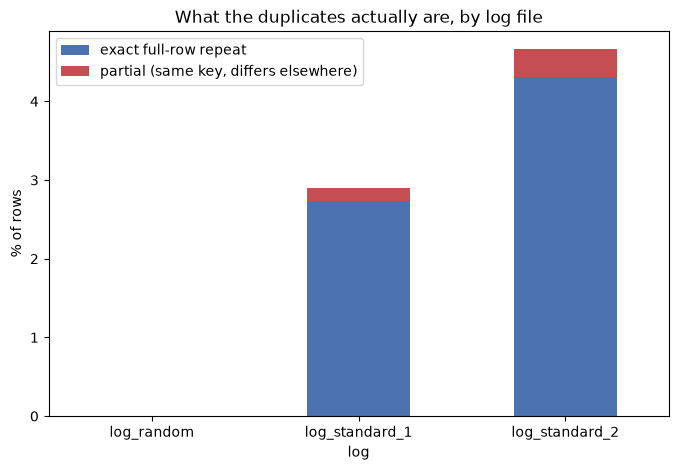

In [8]:
dup_type_df = pd.DataFrame({
    "log": [d["file"] for d in dup_reports],
    "exact full-row repeat": [100 * depth["full_dupe_rows"] / dup["rows_before"]
                               for dup, depth in zip(dup_reports, depth_reports)],
    "partial (same key, differs elsewhere)": [100 * depth["partial_dupe_rows"] / dup["rows_before"]
                                               for dup, depth in zip(dup_reports, depth_reports)],
}).set_index("log")

fig, ax = plt.subplots(figsize=(8, 5))
dup_type_df.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("% of rows")
ax.set_title("What the duplicates actually are, by log file")
ax.legend(title=None)
plt.xticks(rotation=0)

save_fig("duplicate_breakdown_by_log", fig)
plt.show()


I'm comfortable dropping duplicates on the key now. The partial share is small enough in
every file that it isn't going to distort anything downstream, and keeping the first
occurrence is a reasonable, consistent rule.

In [9]:
log_random_clean = log_random.drop_duplicates(subset=["user_id", "video_id", "time_ms"]).copy()
log_standard_1_clean = log_standard_1.drop_duplicates(subset=["user_id", "video_id", "time_ms"]).copy()
log_standard_2_clean = log_standard_2.drop_duplicates(subset=["user_id", "video_id", "time_ms"]).copy()

print("log_random after dedup:", log_random_clean.shape)
print("log_standard_1 after dedup:", log_standard_1_clean.shape)
print("log_standard_2 after dedup:", log_standard_2_clean.shape)


log_random after dedup: (1186049, 19)
log_standard_1 after dedup: (1124532, 19)
log_standard_2 after dedup: (288604, 19)


## Check 2 - Missing targets

`is_click` and `long_view` are the two columns I'll treat as targets later on, so I'm not
willing to impute them. If a row is missing either one, it gets dropped.


In [10]:
def missing_target_report(df: pd.DataFrame, name: str, targets=("is_click", "long_view")) -> dict:
    n_before = len(df)
    present = [t for t in targets if t in df.columns]
    missing_mask = df[present].isna().any(axis=1) if present else pd.Series(False, index=df.index)
    n_missing = missing_mask.sum()
    pct = 100 * n_missing / n_before if n_before else 0
    print(f"{name}: missing target columns found: {present}")
    print(f"{name}: {n_missing:,} rows missing a target out of {n_before:,} ({pct:.3f}%)")
    return {"file": name, "rows_before": n_before, "missing_target_rows": int(n_missing), "pct_missing": pct}


missing_reports = [
    missing_target_report(log_random_clean, "log_random"),
    missing_target_report(log_standard_1_clean, "log_standard_1"),
    missing_target_report(log_standard_2_clean, "log_standard_2"),
]


log_random: missing target columns found: ['is_click', 'long_view']
log_random: 0 rows missing a target out of 1,186,049 (0.000%)
log_standard_1: missing target columns found: ['is_click', 'long_view']
log_standard_1: 0 rows missing a target out of 1,124,532 (0.000%)
log_standard_2: missing target columns found: ['is_click', 'long_view']
log_standard_2: 0 rows missing a target out of 288,604 (0.000%)


Zero missing targets everywhere, which is good, but that check only looked at two
columns. I'd rather know about a null anywhere in any table now, instead of finding out
three phases from now that a feature column has gaps in it.

In [11]:
def full_missing_report(df: pd.DataFrame, name: str) -> pd.Series:
    miss = df.isna().sum()
    miss = miss[miss > 0]
    if len(miss) == 0:
        print(f"{name}: no missing values in any column")
    else:
        print(f"{name}: missing values found -")
        print(miss.to_string())
    print()
    return miss


for _df, _name in [
    (log_random_clean, "log_random"),
    (log_standard_1_clean, "log_standard_1"),
    (log_standard_2_clean, "log_standard_2"),
    (user_features, "user_features"),
    (video_basic, "video_basic"),
    (video_stats, "video_stats"),
]:
    full_missing_report(_df, _name)


log_random: no missing values in any column

log_standard_1: no missing values in any column

log_standard_2: no missing values in any column

user_features: missing values found -
onehot_feat4     874
onehot_feat12    714
onehot_feat13    714
onehot_feat14    714
onehot_feat15    714
onehot_feat16    714
onehot_feat17    714

video_basic: missing values found -
video_duration    239
music_type        203
tag                96

video_stats: no missing values in any column



The interaction logs are completely clean, but a handful of `user_features` one-hot
columns and a few `video_basic` fields (`video_duration`, `music_type`, `tag`) do have some
gaps. None of that affects Phase 1. I'm not using those specific columns yet but I'm
noting it here so it doesn't surprise me when I get to feature engineering in Phase 4.

For now, I'll drop rows missing a target in the interaction logs, same as before:


In [12]:
def drop_missing_targets(df: pd.DataFrame, targets=("is_click", "long_view")) -> pd.DataFrame:
    present = [t for t in targets if t in df.columns]
    return df.dropna(subset=present).copy() if present else df.copy()


log_random_clean = drop_missing_targets(log_random_clean)
log_standard_1_clean = drop_missing_targets(log_standard_1_clean)
log_standard_2_clean = drop_missing_targets(log_standard_2_clean)

print("log_random after target drop:", log_random_clean.shape)
print("log_standard_1 after target drop:", log_standard_1_clean.shape)
print("log_standard_2 after target drop:", log_standard_2_clean.shape)


log_random after target drop: (1186049, 19)
log_standard_1 after target drop: (1124532, 19)
log_standard_2 after target drop: (288604, 19)


## Check 3 - Is `log_random` actually random?

This is the check the whole baseline rate depends on. If exposure in `log_random` isn't
roughly flat across videos, then this file isn't the clean, unbiased source I'm treating it
as, and every number I pull from it later - the baseline click rate, the simulator's
starting point, inherits that bias.


In [13]:
exposure_counts = log_random_clean.groupby("video_id").size()

print("videos:", exposure_counts.shape[0])
print(exposure_counts.describe())


videos: 7583
count    7583.000000
mean      156.408941
std        30.829487
min         1.000000
25%       152.000000
50%       162.000000
75%       171.000000
max       214.000000
dtype: float64


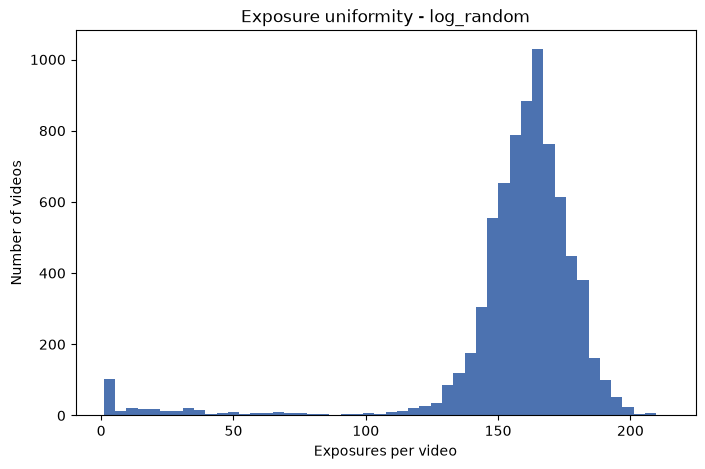

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(exposure_counts.values, bins=50, color="#4C72B0")
ax.set_xlabel("Exposures per video")
ax.set_ylabel("Number of videos")
ax.set_title("Exposure uniformity - log_random")

save_fig("exposure_uniformity", fig)
plt.show()


In [15]:
# Coefficient of variation as a simple flatness score — low is good, high is a red flag.
cv = exposure_counts.std() / exposure_counts.mean()
print(f"Coefficient of variation of exposure counts: {cv:.3f}")


Coefficient of variation of exposure counts: 0.197


A CV of 0.197 tells me the distribution is reasonably tight overall. But an average
statistic like that can still hide a handful of videos sitting way out on the low end, so I
want to check for those specifically before I call this file "uniform."


In [16]:
low_exposure_threshold = exposure_counts.mean() - 3 * exposure_counts.std()
low_exposure_videos = exposure_counts[exposure_counts < max(low_exposure_threshold, 1)]

print(f"Exposure range: min={exposure_counts.min()}, max={exposure_counts.max()}, "
      f"mean={exposure_counts.mean():.1f}")
print(f"Videos more than 3 std below the mean: {len(low_exposure_videos)} "
      f"({100 * len(low_exposure_videos) / len(exposure_counts):.3f}% of all videos)")


Exposure range: min=1, max=214, mean=156.4
Videos more than 3 std below the mean: 272 (3.587% of all videos)


That's a few hundred videos sitting well below the pack. Before I decide whether that
matters, I want to know how much actual traffic those videos represent. If they're a small
slice of total exposure, they're just noise at the edges, not a structural problem.


In [17]:
low_exposure_share = 100 * exposure_counts[low_exposure_videos.index].sum() / exposure_counts.sum()
print(f"Those {len(low_exposure_videos)} videos account for {low_exposure_share:.3f}% "
      f"of total exposure in log_random")


Those 272 videos account for 0.428% of total exposure in log_random


That share is small enough that I'm treating `log_random` as trustworthy overall. I'll
just keep in mind that any per-video estimate for one of these low-exposure videos
specifically would be shaky, and avoid relying on it.


## Baseline rate by segment

Now that I trust `log_random`, I can join it to `user_features` and look at how the
baseline click rate varies by user segment. This is the number Phase 2's power calculator
will use, and it's also the first hint of where a heterogeneous effect might show up later.


In [18]:
merged = log_random_clean.merge(
    user_features[["user_id", "user_active_degree"]],
    on="user_id",
    how="left",
)

baseline_by_segment = merged.groupby("user_active_degree")["is_click"].mean().sort_values(ascending=False)
baseline_by_segment


user_active_degree
day_new              0.247423
low_active           0.234714
middle_active        0.197598
single_low_active    0.193631
high_active          0.190234
2_14_day_new         0.183941
full_active          0.169184
UNKNOWN              0.163701
30day_retention      0.137860
Name: is_click, dtype: float64

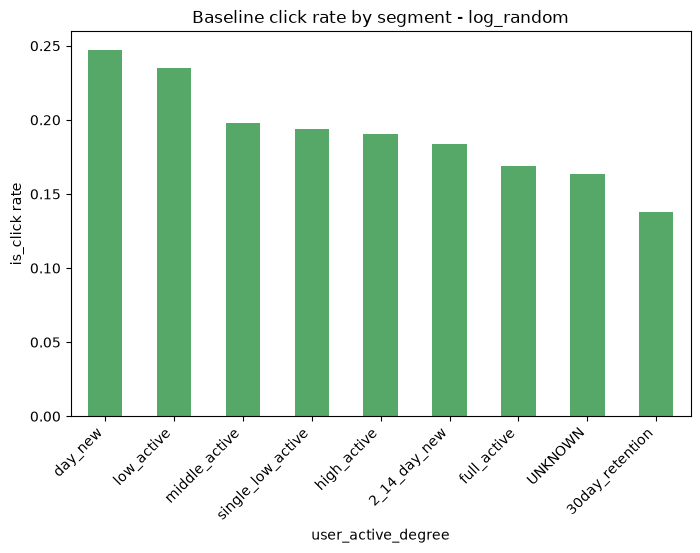

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
baseline_by_segment.plot(kind="bar", ax=ax, color="#55A868")
ax.set_ylabel("is_click rate")
ax.set_title("Baseline click rate by segment - log_random")
plt.xticks(rotation=45, ha="right")

save_fig("baseline_rate_by_segment", fig)
plt.show()


There's a real spread here. Newer users (`day_new`) click at a noticeably higher rate
than long-tenure, retained users (`30day_retention`). That gap is exactly the kind of
heterogeneity I'll want my simulator to plant on purpose in Phase 1, and that the uplift
model in Phase 4 should be able to recover.

## Check 4: Do `date` and `time_ms` agree?

Two different timestamp columns exist in this data, so I want to know they're telling the
same story before I lean on either one. First, a quick eyeball on a handful of rows:


In [20]:
sample = log_random_clean.sample(n=min(10, len(log_random_clean)), random_state=42)

sample_check = sample[["user_id", "video_id", "date", "time_ms"]].copy()
sample_check["time_ms_as_datetime"] = pd.to_datetime(sample_check["time_ms"], unit="ms")
sample_check


,user_id,video_id,date,time_ms,time_ms_as_datetime
116068,2777,7363,20220501,1651416348064,2022-05-01 14:45:48.064
214147,5035,2606,20220429,1651231655854,2022-04-29 11:27:35.854
1088585,24963,7205,20220423,1650720054032,2022-04-23 13:20:54.032
1152940,26500,985,20220426,1650940557006,2022-04-26 02:35:57.006
730476,16705,4553,20220505,1651702465452,2022-05-04 22:14:25.452
91513,2172,6089,20220430,1651307601799,2022-04-30 08:33:21.799
310802,7345,1955,20220505,1651717894144,2022-05-05 02:31:34.144
925260,21185,5940,20220430,1651311264416,2022-04-30 09:34:24.416
1131136,25956,738,20220508,1652004353933,2022-05-08 10:05:53.933
482284,11056,6543,20220502,1651450932218,2022-05-02 00:22:12.218


Ten rows all agreeing doesn't actually prove much. I want a real number over a much
bigger sample before I trust this.


In [21]:
def date_time_agreement(df: pd.DataFrame, name: str, n: int = 5000, seed: int = 42) -> dict:
    sample_n = min(n, len(df))
    s = df.sample(n=sample_n, random_state=seed)
    implied_date = pd.to_datetime(s["time_ms"], unit="ms").dt.strftime("%Y%m%d").astype(int)
    agree_pct = 100 * (implied_date == s["date"]).mean()
    print(f"{name}: date matches the time_ms-implied date on {agree_pct:.3f}% of {sample_n:,} sampled rows")
    return {"file": name, "date_time_agreement_pct": agree_pct, "n_sampled": sample_n}


agreement_reports = [
    date_time_agreement(log_random_clean, "log_random"),
    date_time_agreement(log_standard_1_clean, "log_standard_1"),
    date_time_agreement(log_standard_2_clean, "log_standard_2"),
]


log_random: date matches the time_ms-implied date on 83.320% of 5,000 sampled rows
log_standard_1: date matches the time_ms-implied date on 85.280% of 5,000 sampled rows
log_standard_2: date matches the time_ms-implied date on 84.880% of 5,000 sampled rows


This is exactly why I didn't stop at eyeballing ten rows. The real agreement rate is
only around 83 to 85%, not the near-100% I'd expect if the columns were just two encodings
of the same moment. That's too big a gap to wave off, so I want to understand it rather
than just pick one column and move on.

My first guess is a timezone effect: if `time_ms` is a UTC timestamp but `date` and
`hourmin` were logged in local time, then any interaction near midnight (local time) would
land on a different calendar date once converted through `time_ms`. If that's what's going
on, the mismatches should cluster around the day boundary rather than being spread evenly
through the day.

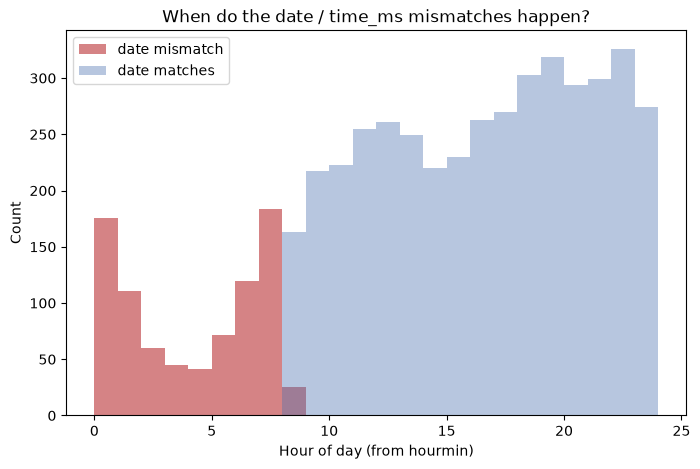

In [22]:
check = log_random_clean.sample(n=5000, random_state=42).copy()
check["implied_date"] = pd.to_datetime(check["time_ms"], unit="ms").dt.strftime("%Y%m%d").astype(int)
check["dates_agree"] = check["implied_date"] == check["date"]
check["hour"] = check["hourmin"] // 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(check.loc[~check["dates_agree"], "hour"], bins=24, range=(0, 24),
        alpha=0.7, color="#C44E52", label="date mismatch")
ax.hist(check.loc[check["dates_agree"], "hour"], bins=24, range=(0, 24),
        alpha=0.4, color="#4C72B0", label="date matches")
ax.set_xlabel("Hour of day (from hourmin)")
ax.set_ylabel("Count")
ax.set_title("When do the date / time_ms mismatches happen?")
ax.legend()

save_fig("date_mismatch_by_hour", fig)
plt.show()


The plot confirms it. Every mismatch falls between hours 0 and 8, and there isn't a single
one from hour 9 onward. That's not noise spread through the day, it's the exact signature
of a fixed 8 hour offset, consistent with `time_ms` being a UTC timestamp while `date` and
`hourmin` were logged in China Standard Time (UTC+8). For any local timestamp between
midnight and 8am, converting through `time_ms` pushes the event back to the previous UTC
day, which is exactly the mismatch window I'm seeing.

So this is a timezone artifact, not corrupted data. `time_ms` and `date` are each
internally reliable, they just don't agree on which calendar day an event near midnight
belongs to. I'll derive "day" from `time_ms` directly wherever the exact boundary matters
(like the daily volume check below), and treat `date` as a rough label elsewhere.


## Check 5: Are the IDs in the logs covered by the feature tables?

Every interaction should be joinable to a user row and a video row. If some slice of
`user_id`s or `video_id`s in the logs is missing from the feature tables, later joins won't
error. They'll just silently drop those rows, which is a much easier problem to miss.

In [23]:
def coverage_report(df: pd.DataFrame, name: str, id_col: str, reference_ids: set, ref_name: str) -> dict:
    log_ids = set(df[id_col].unique())
    missing = log_ids - reference_ids
    pct = 100 * len(missing) / len(log_ids) if log_ids else 0
    print(f"{name}: {len(missing):,} of {len(log_ids):,} {id_col} values "
          f"({pct:.3f}%) not found in {ref_name}")
    return {"file": name, "id_col": id_col, "missing_count": len(missing), "pct_missing": pct}


user_id_set = set(user_features["user_id"].unique())
video_id_set = set(video_basic["video_id"].unique())

coverage_reports = []
for _df, _name in [
    (log_random_clean, "log_random"),
    (log_standard_1_clean, "log_standard_1"),
    (log_standard_2_clean, "log_standard_2"),
]:
    coverage_reports.append(coverage_report(_df, _name, "user_id", user_id_set, "user_features"))
    coverage_reports.append(coverage_report(_df, _name, "video_id", video_id_set, "video_basic"))


log_random: 0 of 27,285 user_id values (0.000%) not found in user_features
log_random: 0 of 7,583 video_id values (0.000%) not found in video_basic
log_standard_1: 0 of 26,210 user_id values (0.000%) not found in user_features
log_standard_1: 0 of 7,538 video_id values (0.000%) not found in video_basic
log_standard_2: 0 of 25,877 user_id values (0.000%) not found in user_features
log_standard_2: 0 of 6,618 video_id values (0.000%) not found in video_basic


Full coverage everywhere. Every user and video I see in any log has a matching feature
row. One less thing to worry about later.

## Check 6: Does the watch-time signal actually make sense?

Watch time is the primary metric for this whole project, so I want to sanity check the
pieces it's built from before I trust it. Two things I'm looking for:

- `play_time_ms` shouldn't wildly exceed `duration_ms`, since that would suggest
  something's off in how these were logged.
- `long_view` should correspond to a meaningfully higher completion ratio than
  `long_view = 0`. If it doesn't, the label isn't measuring what I think it's measuring.

In [24]:
watch = log_random_clean[["play_time_ms", "duration_ms", "long_view"]].copy()
watch = watch[watch["duration_ms"] > 0]
watch["completion_ratio"] = watch["play_time_ms"] / watch["duration_ms"]

over_threshold_pct = 100 * (watch["completion_ratio"] > 1.5).mean()
print(f"Rows where play_time_ms exceeds 1.5x duration_ms (possible replays or bad data): "
      f"{over_threshold_pct:.3f}%")

print()
print("Completion ratio by long_view label:")
print(watch.groupby("long_view")["completion_ratio"].describe())


Rows where play_time_ms exceeds 1.5x duration_ms (possible replays or bad data): 0.647%

Completion ratio by long_view label:
               count      mean       std       min       25%       50%  \
long_view                                                                
0          1049093.0  0.075013  0.123968  0.000000  0.012471  0.029198   
1           100036.0  0.836651  1.043458  0.016167  0.328502  0.810406   

                75%         max  
long_view                        
0          0.080285    0.998900  
1          1.048391  103.129252  


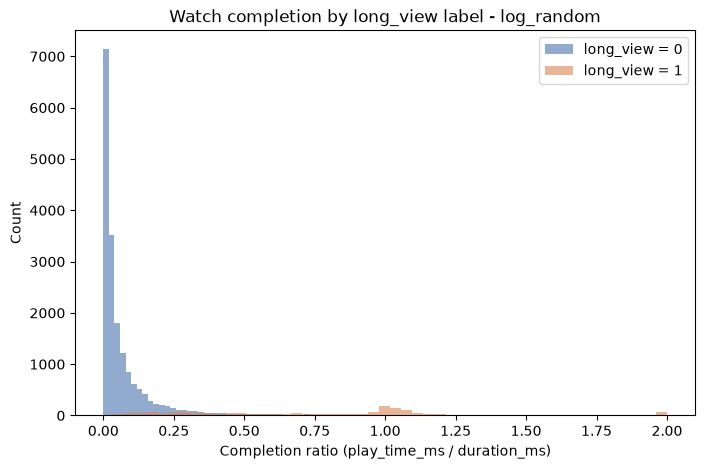

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
sample_watch = watch.sample(n=min(20000, len(watch)), random_state=42)
for lv, color in [(0, "#4C72B0"), (1, "#DD8452")]:
    subset = sample_watch.loc[sample_watch["long_view"] == lv, "completion_ratio"].clip(upper=2)
    ax.hist(subset, bins=50, alpha=0.6, color=color, label=f"long_view = {lv}")
ax.set_xlabel("Completion ratio (play_time_ms / duration_ms)")
ax.set_ylabel("Count")
ax.set_title("Watch completion by long_view label - log_random")
ax.legend()

save_fig("completion_ratio_by_long_view", fig)
plt.show()


This is exactly the separation I want to see: `long_view = 0` rows cluster at a low
completion ratio (mean around 0.08), while `long_view = 1` rows sit much higher (mean
around 0.84, with plenty of full or near-full views). Less than 1% of rows exceed 1.5x the
video duration, which is a small enough sliver that I'm treating it as replays rather than
a data problem. The label is measuring what I expect it to measure.


## Check 7: Daily volume, over time

One more visual check before I move on: I want to see row counts per day for each log, to
catch anything like a missing day or an unexplained spike. This also gives me a feel for the
pre/post split that `log_standard_1` (April 8 to 21) and `log_standard_2` (April 22 to
May 8) will give me for CUPED later. I'm deriving the day from `time_ms` here rather than
`date`, given what I found in Check 4.

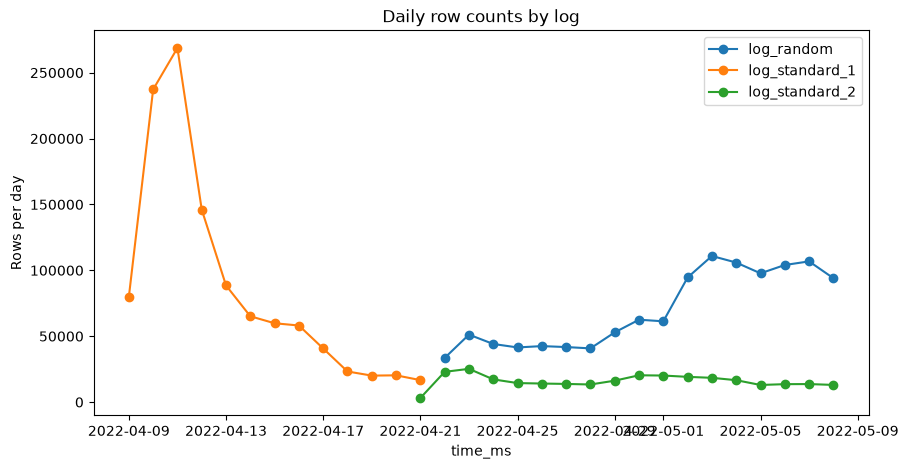

In [26]:
def daily_counts(df: pd.DataFrame) -> pd.Series:
    day = pd.to_datetime(df["time_ms"], unit="ms").dt.date
    return day.value_counts().sort_index()


fig, ax = plt.subplots(figsize=(10, 5))
daily_counts(log_random_clean).plot(ax=ax, marker="o", label="log_random")
daily_counts(log_standard_1_clean).plot(ax=ax, marker="o", label="log_standard_1")
daily_counts(log_standard_2_clean).plot(ax=ax, marker="o", label="log_standard_2")
ax.set_ylabel("Rows per day")
ax.set_title("Daily row counts by log")
ax.legend()

save_fig("daily_volume_by_log", fig)
plt.show()


## Check 8: Is the date range contiguous?

One more thing worth confirming before I call this data solid: no missing days. A gap in coverage would quietly distort anything that depends on day over day continuity, like the pre and post split I'm counting on for CUPED.

In [27]:
def contiguity_report(df, name, date_col="date"):
    days = pd.to_datetime(df[date_col], format="%Y%m%d").dt.date
    observed = sorted(days.unique())
    full_range = pd.date_range(observed[0], observed[-1], freq="D").date
    missing = sorted(set(full_range) - set(observed))
    print(f"{name}: {len(observed)} distinct days observed, {len(missing)} missing, "
          f"range {observed[0]} to {observed[-1]}")
    if missing:
        print(f"{name}: missing days are {missing}")
    return {"file": name, "days_observed": len(observed), "days_missing": len(missing)}


contiguity_reports = [
    contiguity_report(log_random_clean, "log_random"),
    contiguity_report(log_standard_1_clean, "log_standard_1"),
    contiguity_report(log_standard_2_clean, "log_standard_2"),
]

log_random: 17 distinct days observed, 0 missing, range 2022-04-22 to 2022-05-08
log_standard_1: 13 distinct days observed, 0 missing, range 2022-04-09 to 2022-04-21
log_standard_2: 17 distinct days observed, 0 missing, range 2022-04-22 to 2022-05-08


I'm using the `date` column here rather than `time_ms`, since this check is about day level coverage, not the exact boundary issue I found in Check 4.

## Pulling it all together

Before I save a summary, one clarification for myself (and anyone reading this): the
duplicate percentages I quote in Check 1 and the ones in the table below aren't computed
the same way. The first ones count only the *extra* copies of each duplicated row (the ones
I'd actually remove). The "full-row" and "partial" columns below count *every* row involved
in a duplicate group, including the one that gets kept. That's why, for example,
`log_standard_1`'s numbers look roughly double between the two. Both are correct, they're
just answering slightly different questions, so I'm labeling them separately rather than
mixing them into one number.


In [28]:
summary_rows = []
for dup, depth, miss, agree in zip(dup_reports, depth_reports, missing_reports, agreement_reports):
    row = {
        "file": dup["file"],
        "rows_before": dup["rows_before"],
        "pct_duplicates_removed": dup["pct_duplicates"],
        "pct_rows_full_duplicate_group": 100 * depth["full_dupe_rows"] / dup["rows_before"],
        "pct_rows_partial_duplicate_group": 100 * depth["partial_dupe_rows"] / dup["rows_before"],
        "pct_missing_targets": miss["pct_missing"],
        "date_time_agreement_pct": agree["date_time_agreement_pct"],
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df["exposure_cv_log_random"] = cv
display(summary_df)

save_table("data_quality_summary", summary_df)


,file,rows_before,pct_duplicates_removed,pct_rows_full_duplicate_group,pct_rows_partial_duplicate_group,pct_missing_targets,date_time_agreement_pct,exposure_cv_log_random
0,log_random,1186059,0.000843,0.001686,0.000000,0.0,83.32,0.197108
1,log_standard_1,1141112,1.452969,2.730407,0.169747,0.0,85.28,0.197108
2,log_standard_2,295497,2.332680,4.312396,0.347888,0.0,84.88,0.197108


WindowsPath('C:/Users/sabin/splitlab/docs/tables/data_quality_summary.csv')

And here's the single headline report I'll actually refer back to in later phases, the
real numbers, computed directly from the data rather than typed out by hand:

In [29]:
report = {
    "log_random_rows_clean": len(log_random_clean),
    "log_standard_1_rows_clean": len(log_standard_1_clean),
    "log_standard_2_rows_clean": len(log_standard_2_clean),
    "max_duplicate_pct_across_logs": max(r["pct_duplicates"] for r in dup_reports),
    "max_missing_target_pct_across_logs": max(r["pct_missing"] for r in missing_reports),
    "exposure_cv_log_random": cv,
    "exposure_min_log_random": int(exposure_counts.min()),
    "exposure_max_log_random": int(exposure_counts.max()),
    "low_exposure_video_count": int(len(low_exposure_videos)),
    "low_exposure_traffic_share_pct": low_exposure_share,
    "baseline_click_rate_overall": float(log_random_clean["is_click"].mean()),
    "baseline_click_rate_min_segment": float(baseline_by_segment.min()),
    "baseline_click_rate_max_segment": float(baseline_by_segment.max()),
    "min_date_time_agreement_pct": min(r["date_time_agreement_pct"] for r in agreement_reports),
    "max_id_coverage_missing_pct": max(r["pct_missing"] for r in coverage_reports),
    "watch_time_over_threshold_pct": over_threshold_pct,
}

report_df = pd.DataFrame(report.items(), columns=["metric", "value"])
display(report_df)

save_table("data_quality_report", report_df)


,metric,value
0,log_random_rows_clean,1.186049e+06
1,log_standard_1_rows_clean,1.124532e+06
2,log_standard_2_rows_clean,2.886040e+05
3,max_duplicate_pct_across_logs,2.332680e+00
4,max_missing_target_pct_across_logs,0.000000e+00
5,exposure_cv_log_random,1.971082e-01
6,exposure_min_log_random,1.000000e+00
7,exposure_max_log_random,2.140000e+02
8,low_exposure_video_count,2.720000e+02
9,low_exposure_traffic_share_pct,4.283971e-01


WindowsPath('C:/Users/sabin/splitlab/docs/tables/data_quality_report.csv')

## Writing the cleaned data to Parquet

The last thing I want out of this notebook is a clean, reusable copy of the data. I'm writing each cleaned log to `data/processed/` as Parquet, partitioned by date. This is what Phase 2C uploads to S3, and it's much faster to read back than parsing the CSVs again every time.

In [30]:
PROCESSED = Path("../data/processed")


def write_partitioned_parquet(df, name, date_col="date"):
    out_dir = PROCESSED / name
    out_dir.mkdir(parents=True, exist_ok=True)
    df.to_parquet(out_dir, engine="pyarrow", partition_cols=[date_col], index=False)
    print(f"{name}: wrote {len(df):,} rows to {out_dir}, partitioned by {date_col}")


write_partitioned_parquet(log_random_clean, "log_random")
write_partitioned_parquet(log_standard_1_clean, "log_standard_1")
write_partitioned_parquet(log_standard_2_clean, "log_standard_2")

log_random: wrote 1,186,049 rows to ..\data\processed\log_random, partitioned by date
log_standard_1: wrote 1,124,532 rows to ..\data\processed\log_standard_1, partitioned by date
log_standard_2: wrote 288,604 rows to ..\data\processed\log_standard_2, partitioned by date


## Where this leaves me

The data holds up well enough to build on. To summarize what I'm carrying forward into
Phase 2 and beyond:

- **Duplicates and missing targets** are small and now handled, dropped on
  `(user_id, video_id, time_ms)`, first occurrence kept.
- **`log_random` is a fair baseline source.** Exposure is roughly flat (CV about 0.20), and
  the handful of low-exposure videos account for a negligible share of total traffic.
- **The baseline click rate varies meaningfully by segment.** Newer users click more than
  long-tenure ones, which is exactly the kind of heterogeneity I want my simulator to
  plant on purpose, and that Phase 4's uplift model should later be able to recover.
- **`date` and `time_ms` don't always agree**, most likely because of a day-boundary
  timezone effect rather than a data error. I'm deriving "day" from `time_ms` wherever the
  exact boundary matters, and treating `date` as a rough label elsewhere.
- **Every user and video ID in the logs is covered** by the feature tables, so there are no
  silent join losses to worry about.
- **The watch-time signal behaves the way it should.** `long_view` corresponds to a
  clearly higher completion ratio, and implausible values are rare.
- **The date range is contiguous** in every log, no missing days, so the pre and post split for CUPED holds up.
- **The cleaned data is saved as partitioned Parquet** in `data/processed/`, ready for Phase 2C's SQL pipeline.

Everything above is saved to `docs/tables/data_quality_summary.csv` and
`docs/tables/data_quality_report.csv`, and the figures are in `docs/figures/`.

Next up: `core/simulator.py` and `01_simulator.ipynb`, where I calibrate a simulator off
these real numbers and start planting known effects to test every later method against.

## Calibration numbers for the simulator

Before I design anything in Phase 2, I want the simulator to look like the real platform. This cell pulls the remaining rates from log_random. It builds watch time per user day as the sum of play_time_ms in seconds. It also measures how well a user's earlier watch time predicts their later watch time, using log_standard_1 as the pre period and log_standard_2 as the post period. I add these to the same report table so there is one place to look.

In [31]:
def user_day_watch(df):
    out = (df.groupby(["user_id", "date"])["play_time_ms"].sum() / 1000).rename("watch_s")
    return out.reset_index()


def per_user_mean_watch(df):
    return user_day_watch(df).groupby("user_id")["watch_s"].mean()


rand_ud = user_day_watch(log_random_clean)
clicked = log_random_clean["is_click"] == 1

pre_u = per_user_mean_watch(log_standard_1_clean)
post_u = per_user_mean_watch(log_standard_2_clean)
both = pd.concat([pre_u.rename("pre"), post_u.rename("post")], axis=1, join="inner")

users_per_day = log_standard_2_clean.groupby("date")["user_id"].nunique()
all_users = log_standard_2_clean["user_id"].nunique()

extra = {
    "baseline_long_view_rate_overall": float(log_random_clean["long_view"].mean()),
    "baseline_long_view_rate_given_click": float(log_random_clean.loc[clicked, "long_view"].mean()),
    "baseline_like_rate_overall": float(log_random_clean["is_like"].mean()),
    "baseline_follow_rate_overall": float(log_random_clean["is_follow"].mean()),
    "user_day_watch_s_median": float(rand_ud["watch_s"].median()),
    "user_day_watch_s_mean": float(rand_ud["watch_s"].mean()),
    "user_day_watch_s_sd": float(rand_ud["watch_s"].std()),
    "user_day_watch_log_sd": float(np.log(rand_ud.loc[rand_ud["watch_s"] > 0, "watch_s"]).std()),
    "daily_active_share_log_standard_2": float((users_per_day / all_users).mean()),
    "pre_post_users_overlap": int(len(both)),
    "pre_post_watch_corr_raw": float(both["pre"].corr(both["post"])),
    "pre_post_watch_corr_log": float(np.log1p(both["pre"]).corr(np.log1p(both["post"]))),
}
extra_df = pd.DataFrame(extra.items(), columns=["metric", "value"])
display(extra_df)

report_df = pd.concat([report_df, extra_df], ignore_index=True)
save_table("data_quality_report", report_df)

,metric,value
0,baseline_long_view_rate_overall,0.084962
1,baseline_long_view_rate_given_click,0.480554
2,baseline_like_rate_overall,0.004798
3,baseline_follow_rate_overall,0.000261
4,user_day_watch_s_median,9.995000
5,user_day_watch_s_mean,36.897155
6,user_day_watch_s_sd,71.499192
7,user_day_watch_log_sd,1.559069
8,daily_active_share_log_standard_2,0.345892
9,pre_post_users_overlap,25010.000000


WindowsPath('C:/Users/sabin/splitlab/docs/tables/data_quality_report.csv')